In [38]:
# Import libraries
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands

In [39]:
# Load dataset, re-format date
df = pd.read_csv("../data/processed/master_dataset.csv",parse_dates=["date"])
df = df.set_index("date").sort_index()

df.head()

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions
date,,,,,,,,
2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0
2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0
2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0
2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0
2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0


In [40]:
# Target
df["target"] = df["close"].shift(-1)
df[["close", "target"]].head()

,close,target
date,,
2020-01-01,7200.85,6965.71
2020-01-02,6965.71,7344.96
2020-01-03,7344.96,7354.11
2020-01-04,7354.11,7358.75
2020-01-05,7358.75,7758.00


In [41]:
# Close price scale based on period
for lag in [1, 2, 3, 7, 14, 30]:
    df[f"close_lag_{lag}"] = df["close"].shift(lag)

df.head()

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,close_lag_2,close_lag_3,close_lag_7,close_lag_14,close_lag_30
date,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,NaN,NaN,NaN,NaN,NaN
2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,7200.85,NaN,NaN,NaN,NaN
2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,6965.71,7200.85,NaN,NaN,NaN
2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,7344.96,6965.71,NaN,NaN,NaN


In [42]:
# Features based on period
features_to_lag = ["volume", "fear_greed", "hash_rate", "n_transactions"]
lags = [1, 3, 7]

for feat in features_to_lag:
    for lag in lags:
        df[f"{feat}_lag_{lag}"] = df[feat].shift(lag)

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,volume_lag_7,fear_greed_lag_1,fear_greed_lag_3,fear_greed_lag_7,hash_rate_lag_1,hash_rate_lag_3,hash_rate_lag_7,n_transactions_lag_1,n_transactions_lag_3,n_transactions_lag_7
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,37.0,NaN,NaN,1.127185e+08,NaN,NaN,251735.0,NaN,NaN
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,39.0,NaN,NaN,9.671772e+07,NaN,NaN,295567.0,NaN,NaN
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,38.0,37.0,NaN,1.159241e+08,1.127185e+08,NaN,316517.0,251735.0,NaN
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,38.0,39.0,NaN,1.152381e+08,9.671772e+07,NaN,287215.0,295567.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,7963.56162,39.0,29.0,33.0,8.976079e+08,9.436641e+08,1.004328e+09,526246.0,409874.0,712904.0
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,16046.92418,47.0,26.0,47.0,1.000953e+09,1.064992e+09,9.301832e+08,604132.0,593987.0,580030.0
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,13210.72383,40.0,39.0,33.0,9.811977e+08,8.976079e+08,9.369236e+08,567996.0,526246.0,566274.0


In [43]:
# Daily, weekly, monthly returns percent
df["return_1d"] = df["close"].pct_change(1)
df["return_7d"] = df["close"].pct_change(7)
df["return_30d"] = df["close"].pct_change(30)

# Lag the returns so model can use yesterday's return to predict today
df["return_1d_lag_1"] = df["return_1d"].shift(1)
df["return_7d_lag_1"] = df["return_7d"].shift(1)

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,hash_rate_lag_3,hash_rate_lag_7,n_transactions_lag_1,n_transactions_lag_3,n_transactions_lag_7,return_1d,return_7d,return_30d,return_1d_lag_1,return_7d_lag_1
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,NaN,251735.0,NaN,NaN,-0.032654,NaN,NaN,NaN,NaN
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,NaN,295567.0,NaN,NaN,0.054445,NaN,NaN,-0.032654,NaN
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,1.127185e+08,NaN,316517.0,251735.0,NaN,0.001246,NaN,NaN,0.054445,NaN
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,9.671772e+07,NaN,287215.0,295567.0,NaN,0.000631,NaN,NaN,0.001246,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,9.436641e+08,1.004328e+09,526246.0,409874.0,712904.0,-0.001503,-0.001131,0.173290,0.005825,0.013679
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,1.064992e+09,9.301832e+08,604132.0,593987.0,580030.0,0.016450,0.032178,0.186635,-0.001503,-0.001131
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,8.976079e+08,9.369236e+08,567996.0,526246.0,566274.0,0.013079,0.059767,0.171963,0.016450,0.032178


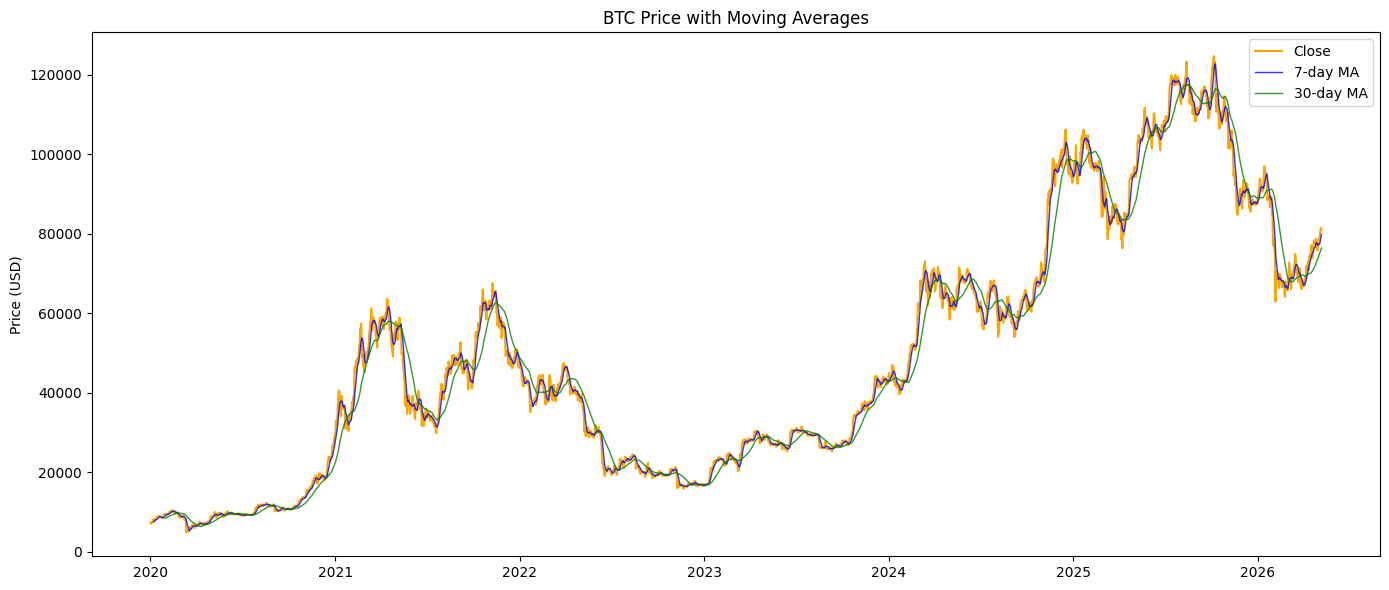

In [44]:
# Moving averages of close price
for window in [7, 14, 30]:
    df[f"close_ma_{window}"] = df["close"].rolling(window=window).mean()

# Visualize against price
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["close"], color="orange", linewidth=1.5, label="Close")
ax.plot(df.index, df["close_ma_7"], color="blue", linewidth=1, label="7-day MA", alpha=0.8)
ax.plot(df.index, df["close_ma_30"], color="green", linewidth=1, label="30-day MA", alpha=0.8)
ax.set_title("BTC Price with Moving Averages")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
# Rolling volatility aka std of return
for window in [7, 14, 30]:
    df[f"volatility_{window}"] = df["return_1d"].rolling(window=window).std()

In [46]:
# Rolling stats for sentiment and on-chain
for window in [7, 14]:
    df[f"fear_greed_ma_{window}"] = df["fear_greed"].rolling(window=window).mean()
    df[f"volume_ma_{window}"] = df["volume"].rolling(window=window).mean()
    df[f"hash_rate_ma_{window}"] = df["hash_rate"].rolling(window=window).mean()

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,close_ma_30,volatility_7,volatility_14,volatility_30,fear_greed_ma_7,volume_ma_7,hash_rate_ma_7,fear_greed_ma_14,volume_ma_14,hash_rate_ma_14
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,74848.543667,0.014141,0.014113,0.019097,35.285714,12687.361234,9.471947e+08,35.000000,13124.974038,9.333929e+08
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,75267.230000,0.013256,0.012979,0.019200,34.285714,14115.366544,9.544825e+08,35.785714,13771.370539,9.408884e+08
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,75662.941333,0.010849,0.013202,0.018885,36.714286,14649.145990,9.617481e+08,37.000000,13916.699726,9.464471e+08


In [47]:
# RSI (Relative Strength Index) - momentum indicator (0–100)
df["rsi_14"] = RSIIndicator(close=df["close"], window=14).rsi()

# Moving Average Convergence Divergence trend indicator
macd = MACD(close=df["close"])
df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_diff"] = macd.macd_diff()

# Bollinger Bands - volatility envelope
bb = BollingerBands(close=df["close"], window=20, window_dev=2)
df["bb_upper"] = bb.bollinger_hband()
df["bb_lower"] = bb.bollinger_lband()
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["close"]

In [48]:
df["day_of_week"] = df.index.dayofweek      
df["day_of_month"] = df.index.day            
df["month"] = df.index.month                 
df["quarter"] = df.index.quarter             
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df[["day_of_week", "month", "is_weekend"]].head()

,day_of_week,month,is_weekend
date,,,
2020-01-01,2,1,0
2020-01-02,3,1,0
2020-01-03,4,1,0
2020-01-04,5,1,1
2020-01-05,6,1,1


In [49]:
# Cyclical encoding for day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Cyclical encoding for month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df[["day_of_week", "dow_sin", "dow_cos", "month", "month_sin", "month_cos"]].head()

,day_of_week,dow_sin,dow_cos,month,month_sin,month_cos
date,,,,,,
2020-01-01,2,0.974928,-0.222521,1,0.5,0.866025
2020-01-02,3,0.433884,-0.900969,1,0.5,0.866025
2020-01-03,4,-0.433884,-0.900969,1,0.5,0.866025
2020-01-04,5,-0.974928,-0.222521,1,0.5,0.866025
2020-01-05,6,-0.781831,0.623490,1,0.5,0.866025


In [50]:
# Data cleaning
df_features = df.dropna()
df_features

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,bb_width,day_of_week,day_of_month,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2020-02-03,9331.59,9618.79,9234.00,9292.24,50892.133451,59.0,1.137859e+08,331012.0,9197.02,9331.51,...,0.155379,0,3,2,1,0,0.000000,1.000000,0.866025,0.500000
2020-02-04,9291.35,9350.00,9093.01,9197.02,53308.175266,56.0,1.014848e+08,309190.0,9612.04,9292.24,...,0.158795,1,4,2,1,0,0.781831,0.623490,0.866025,0.500000
2020-02-05,9197.02,9744.45,9177.22,9612.04,64870.415615,53.0,1.222430e+08,368604.0,9772.00,9197.02,...,0.162046,2,5,2,1,0,0.974928,-0.222521,0.866025,0.500000
2020-02-06,9612.03,9862.57,9526.35,9772.00,64949.706588,61.0,1.037912e+08,315370.0,9813.73,9612.04,...,0.173993,3,6,2,1,0,0.433884,-0.900969,0.866025,0.500000
2020-02-07,9772.00,9885.00,9730.00,9813.73,43966.114632,56.0,1.068665e+08,334938.0,9895.05,9772.00,...,0.186383,4,7,2,1,0,-0.433884,-0.900969,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-02,78231.13,79199.48,78040.00,78686.85,6150.876420,39.0,8.976079e+08,526246.0,78568.57,78231.13,...,0.076371,5,2,5,2,1,-0.974928,-0.222521,0.500000,-0.866025
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,0.075644,6,3,5,2,1,-0.781831,0.623490,0.500000,-0.866025
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,0.075731,0,4,5,2,0,0.000000,1.000000,0.500000,-0.866025


In [51]:
# Set target to the last column for ML 
df_features = df_features.drop(columns=['target']).assign(target=df_features['target'])
df_features

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,close_lag_1,close_lag_2,...,day_of_week,day_of_month,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos,target
date,,,,,,,,,,,,,,,,,,,,,
2020-02-03,9331.59,9618.79,9234.00,9292.24,50892.133451,59.0,1.137859e+08,331012.0,9331.51,9384.61,...,0,3,2,1,0,0.000000,1.000000,0.866025,0.500000,9197.02
2020-02-04,9291.35,9350.00,9093.01,9197.02,53308.175266,56.0,1.014848e+08,309190.0,9292.24,9331.51,...,1,4,2,1,0,0.781831,0.623490,0.866025,0.500000,9612.04
2020-02-05,9197.02,9744.45,9177.22,9612.04,64870.415615,53.0,1.222430e+08,368604.0,9197.02,9292.24,...,2,5,2,1,0,0.974928,-0.222521,0.866025,0.500000,9772.00
2020-02-06,9612.03,9862.57,9526.35,9772.00,64949.706588,61.0,1.037912e+08,315370.0,9612.04,9197.02,...,3,6,2,1,0,0.433884,-0.900969,0.866025,0.500000,9813.73
2020-02-07,9772.00,9885.00,9730.00,9813.73,43966.114632,56.0,1.068665e+08,334938.0,9772.00,9612.04,...,4,7,2,1,0,-0.433884,-0.900969,0.866025,0.500000,9895.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-02,78231.13,79199.48,78040.00,78686.85,6150.876420,39.0,8.976079e+08,526246.0,78231.13,76346.57,...,5,2,5,2,1,-0.974928,-0.222521,0.500000,-0.866025,78568.57
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,78686.85,78231.13,...,6,3,5,2,1,-0.781831,0.623490,0.500000,-0.866025,79861.01
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,78568.57,78686.85,...,0,4,5,2,0,0.000000,1.000000,0.500000,-0.866025,80905.52


In [52]:
# Save features data
df_features.to_csv("../data/processed/features_dataset.csv")